# Homework 8
## By Ram Kakinada
## ECE 580C7

### Question 1
#### The physical model that the forward model is looking at is the creation of the sinogram. Essentially the code models the rotation of the of the image with the transforms.functional.rotate command, and then the code takes slices from 0 to pi to form 2D slices that make our sinogram images. 

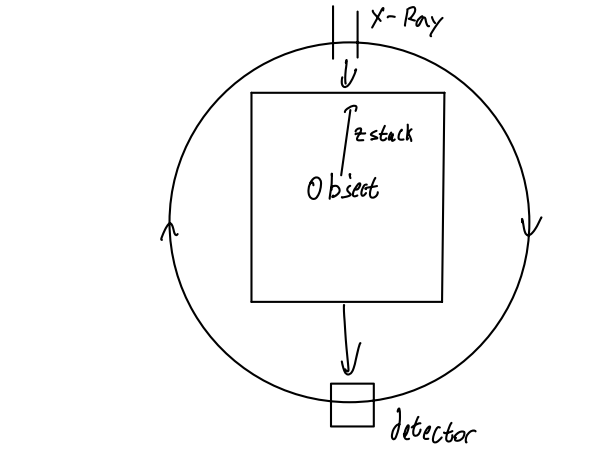

In [2]:
# HW 08: tomography reconstruction
# Starter code by Jesse Wilson (2024) jesse.wilson@colostate.edu
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torchvision.transforms.functional import gaussian_blur
import numpy as np
from random import randint

In [3]:
device = torch.device('cuda:0')

In [4]:
# load the usual suspects
transform = transforms.Compose([
    transforms.ToTensor()])
dataset_train = datasets.MNIST(root='data',train=True,download=True,transform=transform)
dataset_val = datasets.MNIST(root='data',train=False,download=True)


In [5]:
def forwardModel( obj, n_angles=28*2 ):
    # calculate a tomographic sinogram
    # basic code written by MS Copilot.
    # prompt: write pytorch code to generate a tomography sinogram from an image
    # changes from AI-generated code labeled JWW

    angles = np.linspace(0,np.pi,n_angles,endpoint=False)
    sinogram = []

    for angle in angles:
        rotated_obj = transforms.functional.rotate(obj, angle*180/np.pi)
        projection = torch.sum(rotated_obj, dim=2) # (JWW) changed dim=1 to dim=2 to sum along columns

        sinogram.append(projection)

    sinogram = torch.stack(sinogram,dim=2) # (JWW) changed dim=1 to dim=2 to stack into rows rather than channels
    return sinogram


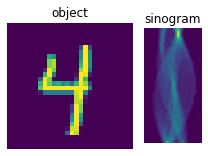

In [33]:
# quick test: generate a random object and sinogram
ind = randint(0,len(dataset_train)-1)
obj = dataset_train[ind][0].unsqueeze(0).to(device)

sinogram = forwardModel(obj)

# plot the results
plt.figure(figsize=(3,6))

plt.subplot(1,3,(1,2))
plt.imshow(obj.cpu().squeeze())
plt.axis('off')
plt.title('object')

plt.subplot(133)
plt.imshow(sinogram.cpu().squeeze())
plt.axis('off')
plt.title('sinogram')

plt.tight_layout()
plt.show()

In [51]:
# 112x28 -> 28x28 encoder decoder network
# uses strided convs instead of conv->maxpool
# uses strided transposed convs instead of upsampling -> conv

class EncDec( nn.Module ):
    def __init__(self):
        super(EncDec,self).__init__()
        
        nFilt = 32
        
        # 56x28 -> 7x7 encoder
        self.enc = nn.Sequential(
            nn.Conv2d(1,nFilt,kernel_size=3,stride=(2,1),padding=1), # 56x28 -> 28x28 (replace !!!!!!!! to get this to work) 
            nn.LeakyReLU(),
            nn.Conv2d(nFilt,nFilt,kernel_size=3,stride=2,padding=1), # 28x28 -> 14x14
            nn.LeakyReLU(),
            nn.Conv2d(nFilt,nFilt,kernel_size=3,stride=2,padding=1), # 14x14 -> 7x7
            nn.LeakyReLU(),
        )

        # 7x7 -> 28x28 decoder
        self.dec = nn.Sequential(
            nn.Conv2d(nFilt,nFilt,kernel_size=3,padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(nFilt,nFilt,kernel_size=3,stride=2,padding=1,output_padding=1), # 7x7 -> 14x14
            nn.LeakyReLU(),
            nn.Conv2d(nFilt,nFilt,kernel_size=3,padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(nFilt,nFilt,kernel_size=3,stride=2,padding=1,output_padding=1), #  14x14 -> 28x28
            nn.LeakyReLU(),
            nn.Conv2d(nFilt,1,kernel_size=3,padding=1),
            nn.LeakyReLU()
        )

    def forward(self, x):
        z = self.enc(x)
        y = self.dec(z)
        return y

net = EncDec().to(device)

In [54]:
# YOUR CODE HERE:

# CONFIRM net.enc() on a sinogram produces a 32x7x7 representation

# CONFIRM net() on a sinogram produces a 1x28x28 output

print("sinogram shape:", sinogram.shape)

encoder_output = net.enc(sinogram)
print("Encoder output shape:", encoder_output.shape)  # Expected: (1, 32, 7, 7)

full_output = net(sinogram)
print("Full network output shape:", full_output.shape)  # Expected: (1, 1, 28, 28)


sinogram shape: torch.Size([1, 1, 56, 28])
Encoder output shape: torch.Size([1, 32, 7, 7])
Full network output shape: torch.Size([1, 1, 28, 28])


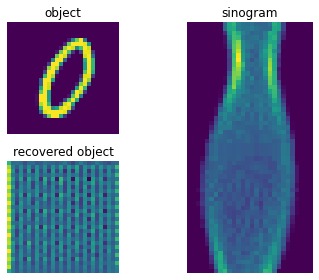

In [55]:
# quick test: generate a random object and sinogram, and try reconstructing with net
ind = randint(0,len(dataset_train)-1)
obj = dataset_train[ind][0].unsqueeze(0).to(device)

sinogram = forwardModel(obj)

obj_est = net(sinogram)

# plot the results
plt.figure(figsize=(6,4))

plt.subplot(221)
plt.imshow(obj.cpu().squeeze())
plt.axis('off')
plt.title('object')

plt.subplot(2,2,(2,4))
plt.imshow(sinogram.cpu().squeeze())
plt.axis('off')
plt.title('sinogram')

plt.subplot(223)
plt.imshow(obj_est.detach().cpu().squeeze())
plt.axis('off')
plt.title('recovered object')

plt.tight_layout()
plt.show()

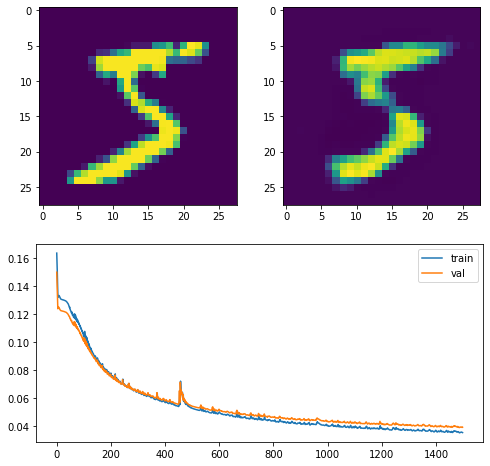

In [57]:
# APPROACH 1: supervised, end-to-end retrieval of object from sinogram
net = EncDec().to(device) # reset the network
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
loss_fn = nn.L1Loss()

# load a limited set of the training data onto the GPU
nTrain = 5000
obj = dataset_train.data.unsqueeze(1).float().to(device)/255.
obj= obj[0:nTrain]

# calculate sinograms objects
sinogram = forwardModel(obj)

# load entire validation set onto the GPU
obj_val = dataset_val.data.unsqueeze(1).float().to(device)/255.
obj_val = obj_val[0:nTrain]

sinogram_val = forwardModel(obj_val)

loss_train_vec = []
loss_val_vec = []

# training loop
n_epochs = 1500
for epoch in range(1,n_epochs):
    obj_est = net(sinogram)

    loss = loss_fn(obj_est,obj)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    loss_train_vec += [loss.item()]
    
    # calculate validation loss
    with torch.no_grad():
        obj_est_val = net(sinogram_val)
        loss_val = loss_fn(obj_est_val, obj_val)
        
    loss_val_vec   += [loss_val.item()]
    
    # plot training/validation loss curves
    clear_output(wait=True)
    plt.figure(figsize=[8,8])
    plt.subplot(221)
    plt.imshow(obj[0].cpu().squeeze())
    plt.subplot(222)
    plt.imshow(obj_est[0].detach().cpu().squeeze())
    plt.subplot(212)
    plt.plot(loss_train_vec)
    plt.plot(loss_val_vec)
    plt.legend(['train','val'])
    plt.show()
    

### Performance of Approach 1
#### I think that this approach does a very good job of reconstructing the sinogram. The error of both the validation and training sets are below 0.05 and it seems that reconstructions for MNIST at least are very accurate. Visually speaking, you can some blurring and loss of information in both the resoltuion and the color but it is still veryt discernable. 

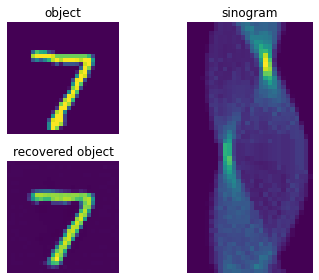

In [68]:
# YOUR CODE HERE TO EVALUATE THE RESULTS VISUALLY ON SOME VALIDATION DATA
sinogram_val = forwardModel(obj_val)
obj_est=net(sinogram_val)

# plot the results
plt.figure(figsize=(6,4))

plt.subplot(221)
plt.imshow(obj_val[0].cpu().squeeze())
plt.axis('off')
plt.title('object')

plt.subplot(2,2,(2,4))
plt.imshow(sinogram_val[0].cpu().squeeze())
plt.axis('off')
plt.title('sinogram')

plt.subplot(223)
plt.imshow(obj_est[0].detach().cpu().squeeze())
plt.axis('off')
plt.title('recovered object')

plt.tight_layout()
plt.show()

In [69]:
# net for deep image prior
# 28x28 -> 7x7 -> 28x28 encoder decoder network
# uses strided convs instead of conv->maxpool
# uses strided transposed convs instead of upsampling -> conv

class EncDecDIP( nn.Module ):
    def __init__(self):
        super(EncDecDIP,self).__init__()
        
        nFilt = 32
        # 112x28 encoder
        self.enc = nn.Sequential(
            nn.Conv2d(1,nFilt,kernel_size=3,stride=2,padding=1), # 28x28 -> 14x14
            nn.LeakyReLU(),
            nn.Conv2d(nFilt,nFilt,kernel_size=3,stride=2,padding=1), # 14x14 -> 7x7
            nn.LeakyReLU()
        )
        
        self.dec = nn.Sequential(
            nn.Conv2d(nFilt,nFilt,kernel_size=3,padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(nFilt,nFilt,kernel_size=3,stride=2,padding=1,output_padding=1), # 7x7 -> 14x14
            nn.LeakyReLU(),
            nn.Conv2d(nFilt,nFilt,kernel_size=3,padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(nFilt,nFilt,kernel_size=3,stride=2,padding=1,output_padding=1), #  14x14 _> 28x28
            nn.LeakyReLU(),
            nn.Conv2d(nFilt,1,kernel_size=3,padding=1),
            nn.LeakyReLU()
        )

    def forward(self, x):
        z = self.enc(x)
        y = self.dec(z)
        return y

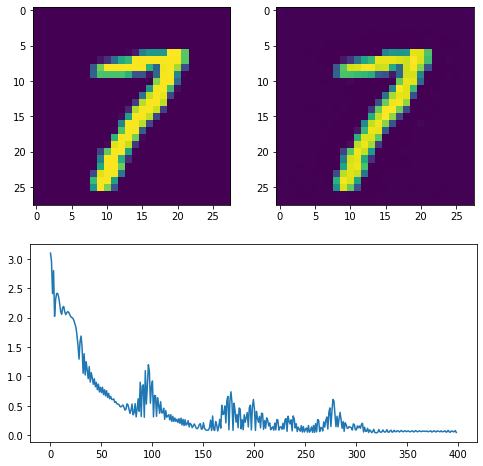

In [90]:
# APPROACH 2: deep image prior on a single sinogram
# unsupervised learning -- the object itself is not directly used in the loss function,
# only the measured sinogram is available during training

net = EncDecDIP().to(device) # reset the network
optimizer = torch.optim.Adam(net.parameters(), lr=0.003)
loss_fn = nn.L1Loss()

# load a single image onto the GPU
ind = randint(0,len(dataset_train)-1)
obj = dataset_train[ind][0].unsqueeze(0).to(device)

sinogram = forwardModel(obj) # measured (simulated) sinogram

seed = torch.randn_like(obj) # random seed for deep image prior

loss_train_vec = []

# training loop
n_epochs = 400
for epoch in range(1,n_epochs):
    # YOUR CODE HERE: pass the seed through the network to generate an estimate of the object
    obj_est = net(seed)

    # YOUR CODE HERE: pass the estimated object through forward model to reconstruct an estimated sinogram
    sinogram_est = forwardModel(obj_est)

    # YOUR CODE HERE: evaluate loss as the L1 difference between the estimated sinogram and the measured sinogram
    loss = loss_fn(sinogram_est,sinogram)
    
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    loss_train_vec += [loss.item()]
     
    # plot training/validation loss curves
    clear_output(wait=True)
    plt.figure(figsize=[8,8])
    plt.subplot(221)
    plt.imshow(obj[0].cpu().squeeze())
    plt.subplot(222)
    plt.imshow(obj_est[0].detach().cpu().squeeze())
    plt.subplot(212)
    plt.plot(loss_train_vec)
    plt.show()
    

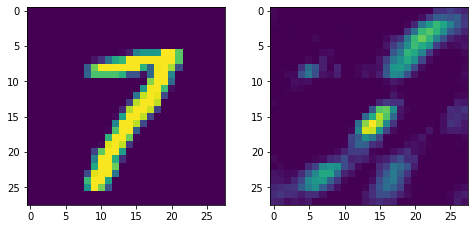

In [97]:
# YOUR CODE HERE TO EVALUATE DIP ON A DIFFERENT Noise
# Generate a new random seed for evaluation
new_seed = torch.randn_like(obj)
obj_est_new = net(new_seed)

clear_output(wait=True)
plt.figure(figsize=[8,8])
plt.subplot(221)
plt.imshow(obj.cpu().squeeze())
plt.subplot(222)
plt.imshow(obj_est_new.detach().cpu().squeeze())
plt.show()

### DIP Performance
#### The Deep image prior network did not work very well at all. It worked very well for the specific type of the noise that we trained it on, but once we switched out the noise profile for something else, the netowrk completely failed and could not recognize the new noise. 

### Supervised Vs. Unsupervised
#### Supervised and Unsupervised learning are an antithesis of one another, but because of that, together they cover a large number of use cases. Supervised learning is great when you have access to the ground truth images or you know exactly what features and patterns you want your network to recognize/find. The problem with this is that you must have one or both of these informations before hand which is both rare and difficult to obtain. Unupervised learning allows the network to find consequnetial patterns and featues of its own which is great as the majority of the time it is unclear what you should be training a netowrk to find. What this means though is that an unsupervised netowrk may recongnize noise as a feature or generally find patterns that are very specific to the data you are training it on which makes the network very brittle. For unsupervise appraoches such as approach one you need to have a good idea of what your are looking for and access to many images while with unsuperivsed you could use something like DIP to train on a single image and without and clue as to what features the network should be looking for. 